In [1]:
import os, sys

# Go up THREE levels (project root directory)
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
project_root
# Append the new path to sys.path
if project_root not in sys.path:
    sys.path.append(project_root)
    print("Project root added to sys.path")
else:
    print("Project root already in sys.path")

Project root added to sys.path


In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import animation

In [3]:
G = nx.dodecahedral_graph()
pos = nx.spectral_layout(G, dim=3)
nodes = np.array([pos[v] for v in G])
edges = np.array([(pos[u], pos[v]) for u, v in G.edges()])

In [4]:
centroids_arr = np.loadtxt("../../data/processed/user-defined-centroids.csv",delimiter=',',skiprows=1,usecols=range(1,4))

pairs = np.loadtxt("../../data/processed/unblocked_pairs_2.csv",delimiter=',',dtype=int)

edges_arr = np.empty(shape=(pairs.shape[0],2,3))
numerator = 0
for (p,q) in pairs:
    edges_arr[numerator] = [centroids_arr[p-1],centroids_arr[q-1]]
    numerator += 1
edges_arr

array([[[1.68453333e+00, 4.85533333e-01, 3.79533333e-01],
        [2.55302667e-01, 6.62302667e-01, 1.11453027e+01]],

       [[1.68453333e+00, 4.85533333e-01, 3.79533333e-01],
        [4.92200000e-01, 9.42200000e-01, 2.66200000e-01]],

       [[1.68453333e+00, 4.85533333e-01, 3.79533333e-01],
        [6.25936000e-01, 1.11049360e+01, 1.05329360e+01]],

       ...,

       [[1.01928333e+01, 2.31983333e+00, 2.41883333e+00],
        [2.06266667e-03, 2.26106267e+00, 2.25206267e+00]],

       [[8.99126600e+00, 2.75266000e-01, 6.00326600e+00],
        [8.28920000e+00, 9.58200000e-01, 6.98120000e+00]],

       [[4.18340000e+00, 3.66240000e+00, 3.95340000e+00],
        [4.42053333e+00, 4.53953333e+00, 3.72153333e+00]]],
      shape=(3597, 2, 3))

In [5]:
data = np.loadtxt(
    "C:/Users/user/OneDrive/Documents/intern-stuff/git/kmc-charge-transport-organic-semiconductor/data/e-coupling_with_nn_distance.txt",
    delimiter="\t",
    skiprows=1,
)

mol_i, mol_j_nearest, extracted_value, Distance_nm, NN_Distance_nm = zip(*data)
mol_i = list(map(int,mol_i))
mol_j_nearest = list(map(int,mol_j_nearest))
e_coupled_pairs = list(zip(mol_i, mol_j_nearest))
e_coupled_pairs_arr = [(None,)] * len(e_coupled_pairs)#np.empty(shape=[len(e_coupled_pairs),2],dtype=int)
num = 0
for (p,q) in e_coupled_pairs:
    if p > q:
        e_coupled_pairs_arr[num] = (q,p)
    else:
        e_coupled_pairs_arr[num] = (p,q)
    num +=1

unique_pairs = list(set(e_coupled_pairs_arr))
seen = set()
duplicates = []

for item in e_coupled_pairs_arr:
    if item in seen:
        if item not in duplicates:
            duplicates.append(item)
    else:
        seen.add(item)

print(duplicates)

# e_coupled_pairs_arr = np.unique(e_coupled_pairs_arr,axis=0)

[(1005, 1028), (1034, 1048), (1001, 1080), (1007, 1163), (1129, 1165), (1026, 1178), (1060, 1197), (115, 1199), (1169, 1218), (1040, 1242), (1089, 1262), (126, 1101), (1226, 1285), (104, 1292), (1139, 1300), (1267, 1315), (1102, 1318), (1206, 1330), (117, 1333), (1136, 1336), (1033, 1340), (1289, 1351), (11, 135), (1240, 1362), (1095, 1369), (1024, 1374), (1194, 1377), (1042, 1391), (1293, 1392), (139, 1047), (13, 1074), (1087, 1404), (1186, 1415), (114, 1425), (142, 1120), (1277, 1432), (1248, 1439), (1027, 1440), (1013, 1442), (1196, 1443), (1110, 1449), (144, 1388), (1255, 1462), (1279, 1470), (1046, 1487), (123, 1489), (146, 1491), (1078, 1493), (149, 1317), (15, 1140), (162, 1332), (170, 1409), (186, 1230), (187, 1017), (188, 1081), (191, 1481), (201, 1066), (205, 1419), (207, 1364), (208, 1381), (20, 1288), (217, 1385), (220, 1179), (221, 1099), (229, 1143), (232, 1173), (234, 235), (239, 1061), (185, 240), (241, 1146), (242, 1305), (253, 1032), (178, 260), (269, 1268), (26, 1437

In [6]:
from utils import mic_helper

e_coupled_pairs_dict = {}
for item in e_coupled_pairs:
    p, q = item
    index = e_coupled_pairs.index(item)
    
    e_coupling = extracted_value[index]
    distance = mic_helper.mic_distance(a= centroids_arr[p-1], b= centroids_arr[q-1], box_dimensions=11.24798)
    
    if p < q:
        pair_order = (p,q)
    else:
        pair_order = (q,p)

    if item in e_coupled_pairs_dict: # if duplicate
        if current_value := e_coupled_pairs_dict[item]["e_coupling"] < e_coupling:
            e_coupled_pairs_dict[pair_order] = {"e_coupling": e_coupling, "distance": distance}
    else:
        e_coupled_pairs_dict[pair_order] = {"e_coupling": e_coupling, "distance": distance}

print(e_coupled_pairs_dict)

{(698, 1000): {'e_coupling': np.float64(0.0086763445541123), 'distance': 1.059886943656414}, (1001, 1080): {'e_coupling': np.float64(0.0522194249137626), 'distance': 0.8112603692198121}, (758, 1002): {'e_coupling': np.float64(0.0244441753032811), 'distance': 0.8678944348248806}, (1003, 1459): {'e_coupling': np.float64(0.0306991520067734), 'distance': 0.9251022319751113}, (1005, 1028): {'e_coupling': np.float64(0.009611212783183), 'distance': 0.9001331179331203}, (16, 1006): {'e_coupling': np.float64(0.0550998780513319), 'distance': 0.500419344150482}, (1007, 1163): {'e_coupling': np.float64(0.3328845358823565), 'distance': 0.5986731328529752}, (405, 1008): {'e_coupling': np.float64(0.0764020618498078), 'distance': 1.4464720686341188}, (576, 1011): {'e_coupling': np.float64(0.0609941396976673), 'distance': 0.7977986462761135}, (180, 1012): {'e_coupling': np.float64(0.0269324181396068), 'distance': 0.9840289985564437}, (1013, 1442): {'e_coupling': np.float64(0.0015448969730038), 'distanc

In [7]:
pairs_distance = {}

for (p,q) in pairs:
    distance = mic_helper.mic_distance(a= centroids_arr[p-1], b= centroids_arr[q-1], box_dimensions=11.24798)
    pairs_distance[(p,q)] = {"distance": distance}

In [8]:
G = nx.Graph()
G.add_nodes_from(list(range(1,1502)))
G.add_edges_from(pairs)

# can check how many edges are connected per node on average
avg_neighbour_degree_dict = nx.average_neighbor_degree(G)
total = 0 
for key in avg_neighbour_degree_dict:
    total += avg_neighbour_degree_dict[key]

avg_neighbour_degree_value = total/1501
print(avg_neighbour_degree_dict)
print(avg_neighbour_degree_value)

nx.set_edge_attributes(G,e_coupled_pairs_dict)

print(G.edges(data=True))

{1: 6.0, 2: 4.857142857142857, 3: 5.0, 4: 5.8, 5: 5.0, 6: 6.4, 7: 6.5, 8: 6.666666666666667, 9: 6.571428571428571, 10: 5.0, 11: 4.6, 12: 5.6, 13: 7.0, 14: 5.285714285714286, 15: 4.75, 16: 5.25, 17: 5.833333333333333, 18: 5.4, 19: 5.25, 20: 5.857142857142857, 21: 4.75, 22: 3.5, 23: 4.75, 24: 6.0, 25: 6.25, 26: 6.0, 27: 4.666666666666667, 28: 4.833333333333333, 29: 5.75, 30: 5.5, 31: 5.6, 32: 5.0, 33: 5.0, 34: 5.0, 35: 6.0, 36: 7.0, 37: 4.0, 38: 4.666666666666667, 39: 4.0, 40: 6.25, 41: 7.0, 42: 5.5, 43: 4.833333333333333, 44: 4.6, 45: 4.428571428571429, 46: 5.555555555555555, 47: 6.0, 48: 4.625, 49: 5.5, 50: 6.666666666666667, 51: 4.5, 52: 6.5, 53: 4.0, 54: 5.875, 55: 6.0, 56: 5.166666666666667, 57: 7.0, 58: 6.2, 59: 5.5, 60: 5.6, 61: 5.6, 62: 5.285714285714286, 63: 3.0, 64: 5.285714285714286, 65: 5.857142857142857, 66: 4.333333333333333, 67: 3.8, 68: 3.0, 69: 5.0, 70: 3.5, 71: 6.0, 72: 5.5, 73: 4.75, 74: 5.75, 75: 5.5, 76: 4.6, 77: 6.666666666666667, 78: 5.666666666666667, 79: 4.333333

In [9]:
# show edges without e-coupling
edges_without_attributes=[]
for u,v, data in G.edges(data=True):
    if not data:
        edges_without_attributes.append((u,v))

edges_without_attributes

[(1, np.int64(2)),
 (1, np.int64(4)),
 (1, np.int64(18)),
 (1, np.int64(359)),
 (1, np.int64(847)),
 (2, np.int64(3)),
 (2, np.int64(4)),
 (2, np.int64(18)),
 (2, np.int64(127)),
 (2, np.int64(780)),
 (2, np.int64(984)),
 (3, np.int64(147)),
 (3, np.int64(258)),
 (3, np.int64(1014)),
 (4, np.int64(226)),
 (4, np.int64(1206)),
 (4, np.int64(1330)),
 (5, np.int64(443)),
 (5, np.int64(760)),
 (5, np.int64(1355)),
 (6, np.int64(302)),
 (6, np.int64(436)),
 (6, np.int64(606)),
 (6, np.int64(664)),
 (6, np.int64(1358)),
 (7, np.int64(711)),
 (8, np.int64(131)),
 (8, np.int64(346)),
 (8, np.int64(700)),
 (8, np.int64(1219)),
 (8, np.int64(1261)),
 (9, np.int64(558)),
 (9, np.int64(591)),
 (9, np.int64(711)),
 (9, np.int64(845)),
 (9, np.int64(986)),
 (9, np.int64(1172)),
 (9, np.int64(1490)),
 (10, np.int64(125)),
 (10, np.int64(418)),
 (10, np.int64(587)),
 (10, np.int64(1153)),
 (11, np.int64(73)),
 (11, np.int64(1043)),
 (11, np.int64(1064)),
 (11, np.int64(1067)),
 (11, np.int64(1183)),
 

In [10]:
# add distance of other edges
nx.set_edge_attributes(G,pairs_distance)
G.edges(data=True)

EdgeDataView([(1, np.int64(2), {'distance': 1.5187082744209524}), (1, np.int64(4), {'distance': 1.2818142091062443}), (1, np.int64(18), {'distance': 1.6473728529898732}), (1, np.int64(359), {'distance': 1.365708368088395}), (1, np.int64(847), {'distance': 0.9322068010908309}), (2, np.int64(3), {'distance': 1.3868164224659782}), (2, np.int64(4), {'distance': 0.5201282061133264}), (2, np.int64(18), {'distance': 1.0774716960242303}), (2, np.int64(127), {'distance': 0.9662930747525139}), (2, np.int64(780), {'distance': 1.0118261151245307}), (2, np.int64(984), {'distance': 1.31492795423222}), (3, np.int64(147), {'distance': 1.4089418817069777}), (3, np.int64(258), {'distance': 1.291210447241916}), (3, np.int64(1014), {'distance': 1.127832041585982}), (4, np.int64(226), {'distance': 0.9288197889795419}), (4, np.int64(1206), {'distance': 0.6325496660342176}), (4, np.int64(1330), {'distance': 0.6894504308988909}), (5, np.int64(443), {'distance': 1.5199320803461362}), (5, np.int64(760), {'dista

In [11]:
nodes = centroids_arr
edges = edges_arr

MovieWriter ffmpeg unavailable; using Pillow instead.


KeyboardInterrupt: 

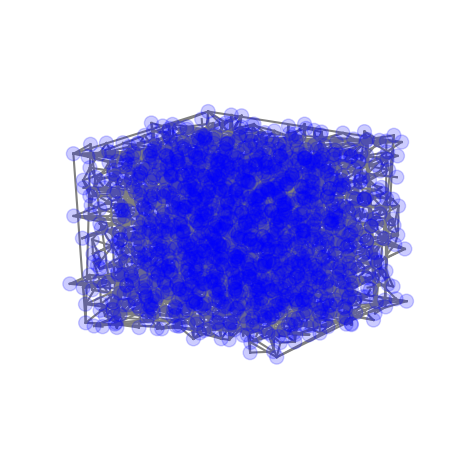

In [202]:
def init():
    ax.clear()
    ax.scatter(*nodes.T, alpha=0.2, s=100, color="blue")
    for vizedge in edges:
        ax.plot(*vizedge.T, color="gray")
    ax.grid(False)
    ax.set_axis_off()


def _frame_update(index):
    ax.view_init(index * 0.2, index * 0.5)


fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
fig.tight_layout()

ani = animation.FuncAnimation(
    fig,
    _frame_update,
    init_func=init,
    interval=50,
    cache_frame_data=False,
    frames=100,
)

ani.save(filename="temp.gif")
plt.show()